UPLOAD & LOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('Dataset_PIR.csv')
df.head()

Saving Dataset_PIR.csv to Dataset_PIR.csv


,Tanggal,Interval Mulai,Interval Selesai,t (interval),count,durasi aktif,lag1,lag2,lag3,lag4,lag5,lag6,avg30,avg60,delta1,label
0,2026-05-14 00:00:00,2026-05-14 12:45:37,2026-05-14 12:55:37,1,11,94.701,0,0,0,0,0,0,11.0,11.00,0,tinggi
1,2026-05-14 00:00:00,2026-05-14 12:55:48,2026-05-14 13:05:37,2,6,44.100,11,0,0,0,0,0,8.5,8.50,-5,tinggi
2,2026-05-14 00:00:00,2026-05-14 13:05:43,2026-05-14 13:15:37,3,4,35.000,6,11,0,0,0,0,7.0,7.00,-2,sedang
3,2026-05-14 00:00:00,2026-05-14 13:15:44,2026-05-14 13:25:37,4,2,15.500,4,6,11,0,0,0,4.0,5.75,-2,sedang
4,2026-05-14 00:00:00,2026-05-14 13:25:45,2026-05-14 13:35:37,5,3,26.300,2,4,6,11,0,0,3.0,5.20,1,sedang


BERSIHKAN DATA

In [ ]:
df = df.dropna().reset_index(drop=True)

MEMISAHKAN FITUR & LABEL

In [ ]:
X = df[['count','durasi aktif','lag1','lag2','lag3','lag4','lag5','lag6',
        'avg30','avg60','delta1']]

y = df['label']

ENCODING LABEL

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'rendah': np.int64(0), 'sedang': np.int64(1), 'tinggi': np.int64(2)}


SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

TRAINING SVC

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf',   # paling umum
    C=1.0,
    gamma='scale'
)

model_svm.fit(X_train, y_train)

SVC()

PREDIKSI

In [ ]:
y_pred = model_svm.predict(X_test)

EVALUASI MODEL

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.9228187919463087
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       179
           1       0.83      0.61      0.70        41
           2       0.97      0.96      0.97        78

    accuracy                           0.92       298
   macro avg       0.91      0.85      0.87       298
weighted avg       0.92      0.92      0.92       298



CONFUSION MATRIX

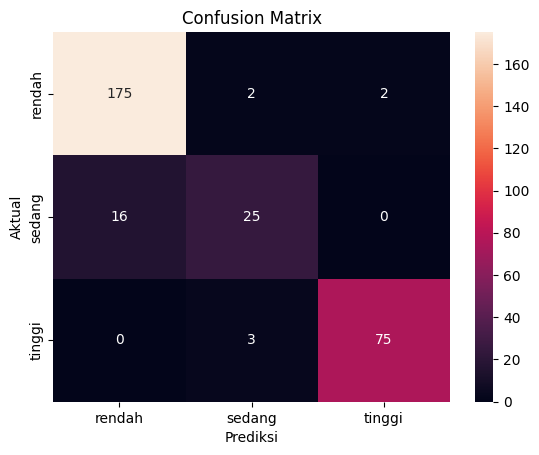

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

CEK OVERFITTING

In [ ]:
# CEK OVERFITTING - bandingkan akurasi train vs test
y_pred_train = model_svm.predict(X_train)
y_pred_test  = model_svm.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
selisih   = acc_train - acc_test

print(f"Akurasi Train : {acc_train:.4f}")
print(f"Akurasi Test  : {acc_test:.4f}")
print(f"Selisih       : {selisih:.4f}")
print()

if selisih < 0.02:
    print("Kesimpulan: TIDAK overfitting — model generalisasi dengan baik")
elif selisih < 0.05:
    print("Kesimpulan: OVERFITTING RINGAN — masih bisa diterima")
else:
    print("Kesimpulan: OVERFITTING — perlu diatasi")

Akurasi Train : 0.9243
Akurasi Test  : 0.9228
Selisih       : 0.0015

Kesimpulan: TIDAK overfitting — model generalisasi dengan baik


SIMPAN MODEL & SCALER

In [ ]:
import joblib

joblib.dump(model_svm, 'model_svm_klasifikasi.pkl')
joblib.dump(scaler, 'scaler_svm.pkl')
files.download('model_svm_klasifikasi.pkl')
files.download('scaler_svm.pkl')
print('Model dan scaler berhasil disimpan dan didownload!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model dan scaler berhasil disimpan dan didownload!
